<a href="https://colab.research.google.com/github/A-ros1076/BUS118s/blob/Dev/Ad_Optimization_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ad Optimization Agent
**Course:** BUS118s — AI and Business Applications

An AI agent that reads ad performance data from a CSV, analyzes channel metrics, and reallocates daily budget across Search, Social, and Display to maximize conversions using LangGraph + GPT-4o-mini.


In [1]:
# ============================================================
# Install required libraries
# langgraph: framework for stateful, multi-step agent workflows
# langchain / langchain_openai: LLM integration and tool calling
# pandas: data manipulation
# matplotlib: charting for evaluation
# ============================================================
!pip install langgraph langchain langchain_openai pydantic pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 12.0 MB/s eta 0:00:00


In [2]:
# ============================================================
# Imports and API Key Configuration
# ============================================================
import os
import json
import operator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import TypedDict, Annotated, List
from copy import deepcopy

# LangChain / LangGraph imports
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END

# ── API Key Setup ──────────────────────────────────────────────
# Securely load the API key from Colab Secrets (never hard-code keys).
# To set this up: click the key icon in the left sidebar of Colab,
# add a secret named OPENAI_API_KEY with your key value.
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("Libraries loaded and API key configured.")

Libraries loaded and API key configured.


In [3]:
# ============================================================
# Generate Synthetic Ad Performance CSV
# ============================================================
# Search = high intent, expensive clicks, strong conversions
# Social = starts weak, improves after day 10 (finds its audience)
# Display = cheap clicks, lots of impressions, weak conversions
#
# All data is generated with an equal budget split ($333.33/channel)
# to establish a fair baseline for comparison.
# ============================================================

np.random.seed(42)  # Reproducible results

NUM_DAYS = 21
CHANNELS = ["Search", "Social", "Display"]
DAILY_BUDGET = 1000.0
EQUAL_SPEND = round(DAILY_BUDGET / len(CHANNELS), 2)  # $333.33

records = []

for day in range(1, NUM_DAYS + 1):
    for ch in CHANNELS:

        # ── Channel-specific profiles ─────────────────────────
        # Each channel has a different cost-per-click (CPC),
        # click-through rate (CTR), and conversion rate (CVR).
        # np.random.normal adds realistic day-to-day variance.

        if ch == "Search":
            # Search: expensive but high-converting
            cpc = max(0.50, np.random.normal(2.00, 0.30))
            ctr = max(0.01, np.random.normal(0.035, 0.008))
            cvr = max(0.005, np.random.normal(0.065, 0.015))

        elif ch == "Social":
            # Social: mid-range cost, conversion rate improves after day 10
            # This simulates the campaign "finding its audience"
            base_cvr = 0.025 if day <= 10 else 0.045
            cpc = max(0.20, np.random.normal(0.80, 0.15))
            ctr = max(0.005, np.random.normal(0.015, 0.004))
            cvr = max(0.003, np.random.normal(base_cvr, 0.008))

        else:  # Display
            # Display: very cheap clicks but poor conversion
            cpc = max(0.05, np.random.normal(0.25, 0.06))
            ctr = max(0.002, np.random.normal(0.004, 0.001))
            cvr = max(0.001, np.random.normal(0.008, 0.003))

        # ── Derive metrics from the profiles ──────────────────
        spend = EQUAL_SPEND
        clicks = max(1, int(spend / cpc))           # clicks = budget / cost_per_click
        impressions = max(clicks, int(clicks / ctr)) # impressions = clicks / click_through_rate
        conversions = max(0, int(clicks * cvr))      # conversions = clicks * conversion_rate

        records.append({
            "date": f"2025-01-{day:02d}",
            "channel": ch,
            "spend": spend,
            "impressions": impressions,
            "clicks": clicks,
            "conversions": conversions
        })

# Build DataFrame and save to CSV
df = pd.DataFrame(records)
df.to_csv("ad_performance.csv", index=False)

print(f"Generated {len(df)} rows: {NUM_DAYS} days x {len(CHANNELS)} channels")
print(f"CSV saved as ad_performance.csv\n")
print(df.head(9).to_string(index=False))

Generated 63 rows: 21 days x 3 channels
CSV saved as ad_performance.csv

      date channel  spend  impressions  clicks  conversions
2025-01-01  Search 333.33         4573     155           11
2025-01-01  Social 333.33        23038     324            7
2025-01-01 Display 333.33       202624     966            6
2025-01-02  Search 333.33         4921     154            8
2025-01-02  Social 333.33        54172     398            4
2025-01-02 Display 333.33       515873    1541           13
2025-01-03  Search 333.33         8100     192           16
2025-01-03  Social 333.33        28487     435            5
2025-01-03 Display 333.33       372908    1533            6


In [4]:
# ============================================================
# Load and Explore the Dataset
# ============================================================
# Quick sanity check: compute summary stats per channel to verify
# the data looks realistic before feeding it to the agent.
# ============================================================

df = pd.read_csv("ad_performance.csv")

print("=== Per-Channel Summary (All 21 Days) ===\n")

for ch in CHANNELS:
    ch_data = df[df["channel"] == ch]
    total_spend = ch_data["spend"].sum()
    total_clicks = ch_data["clicks"].sum()
    total_conv = ch_data["conversions"].sum()
    total_impr = ch_data["impressions"].sum()

    avg_ctr = (total_clicks / total_impr * 100) if total_impr > 0 else 0
    avg_cvr = (total_conv / total_clicks * 100) if total_clicks > 0 else 0
    avg_cpa = (total_spend / total_conv) if total_conv > 0 else float("inf")

    print(f"{ch:>8s}  |  Spend: ${total_spend:,.0f}  |  Clicks: {total_clicks:,}  |  "
          f"Conv: {total_conv:,}  |  CTR: {avg_ctr:.2f}%  |  CVR: {avg_cvr:.2f}%  |  "
          f"CPA: ${avg_cpa:.2f}")

print(f"\nTotal baseline conversions (equal split): {df['conversions'].sum()}")

=== Per-Channel Summary (All 21 Days) ===

  Search  |  Spend: $7,000  |  Clicks: 3,508  |  Conv: 207  |  CTR: 3.26%  |  CVR: 5.90%  |  CPA: $33.82
  Social  |  Spend: $7,000  |  Clicks: 8,648  |  Conv: 306  |  CTR: 1.34%  |  CVR: 3.54%  |  CPA: $22.88
 Display  |  Spend: $7,000  |  Clicks: 28,965  |  Conv: 218  |  CTR: 0.37%  |  CVR: 0.75%  |  CPA: $32.11

Total baseline conversions (equal split): 731


In [5]:
# ============================================================
# Agent State Definition, LLM Initialization, and Global Tracker
# ============================================================

# ── Agent State ────────────────────────────────────────────────
# This TypedDict defines what information flows between nodes
# in the LangGraph workflow. LangGraph passes this state object
# from node to node automatically.

class AgentState(TypedDict):
    """
    messages: conversation history between the agent and tools
    campaign_data: the current day's performance metrics (dict)
    next_action: routing flag ("call_tool" or "FINISH")
    """
    messages: Annotated[List[BaseMessage], operator.add]
    campaign_data: dict
    next_action: str


# ── LLM Initialization ────────────────────────────────────────
# GPT-4o-mini: fast, cheap, and reliable for tool-calling tasks.
# temperature=0 makes the output deterministic (same input = same output),
# which is important for reproducible optimization decisions.

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


# ── Global Optimization Tracker ────────────────────────────────
# This dictionary persists across daily agent invocations.
# It tracks the current budget split, the full decision history,
# and provides shared state that the tools can read/write.
# We use a global dict because LangChain tools are standalone
# functions that need access to optimization state.

tracker = {
    "daily_budget": DAILY_BUDGET,
    # Start with equal split on day 1
    "current_allocation": {"Search": 33.33, "Social": 33.33, "Display": 33.34},
    # Stores every decision the agent makes (day, allocation, reasoning)
    "decisions": [],
    # Stores the allocation used on each day (index 0 = day 1)
    "allocation_history": [{"Search": 33.33, "Social": 33.33, "Display": 33.34}],
    # The metrics for the current day (set before each agent run)
    "current_metrics": {},
    # Which day the agent is currently optimizing for
    "current_day": 1,
}

print("Agent state, LLM, and tracker initialized.")

Agent state, LLM, and tracker initialized.


In [6]:
# ============================================================
# Tool Definitions
# ============================================================
# These are the "actions" the LLM agent can take. LangChain's
# @tool decorator turns Python functions into callable tools
# that the LLM can invoke via function calling.
#
# We define one tool: reallocate_budget
# It takes new percentage allocations + a reasoning string,
# enforces all guardrails, and logs the decision.
# ============================================================

@tool
def reallocate_budget(
    search_pct: float,
    social_pct: float,
    display_pct: float,
    reasoning: str
) -> str:
    """Reallocate tomorrow's daily ad budget across Search, Social, and Display channels.

    Args:
        search_pct: Percentage of budget for Search (0-100).
        social_pct: Percentage of budget for Social (0-100).
        display_pct: Percentage of budget for Display (0-100).
        reasoning: Explanation of why this allocation was chosen.

    Returns:
        Confirmation message showing the final allocation after guardrail enforcement.
    """
    proposed = {"Search": search_pct, "Social": social_pct, "Display": display_pct}
    current = tracker["current_allocation"]
    day = tracker["current_day"]

    # ── GUARDRAIL 1: Normalize so percentages sum to 100 ──────
    total = sum(proposed.values())
    if abs(total - 100.0) > 0.5:
        # If the LLM's numbers don't sum to 100, scale them proportionally
        for ch in proposed:
            proposed[ch] = round(proposed[ch] / total * 100, 2)

    # ── GUARDRAIL 2: Enforce minimum floor of 10% per channel ─
    for ch in proposed:
        if proposed[ch] < 10.0:
            proposed[ch] = 10.0

    # Re-normalize after applying floor (steal from the largest)
    total = sum(proposed.values())
    if total > 100.0:
        largest = max(proposed, key=proposed.get)
        proposed[largest] -= (total - 100.0)
    elif total < 100.0:
        largest = max(proposed, key=proposed.get)
        proposed[largest] += (100.0 - total)

    # ── GUARDRAIL 3: Cap changes at +/-20 percentage points ───
    # This prevents the agent from making drastic swings that
    # could destabilize performance if the data is noisy.
    adjusted = {}
    for ch in proposed:
        diff = proposed[ch] - current[ch]
        if diff > 20.0:
            adjusted[ch] = round(current[ch] + 20.0, 2)
        elif diff < -20.0:
            adjusted[ch] = round(current[ch] - 20.0, 2)
        else:
            adjusted[ch] = round(proposed[ch], 2)

    # Final normalization to ensure exactly 100%
    remainder = 100.0 - sum(adjusted.values())
    largest = max(adjusted, key=adjusted.get)
    adjusted[largest] = round(adjusted[largest] + remainder, 2)

    # ── Log the decision ──────────────────────────────────────
    decision = {
        "day": day,
        "previous_allocation": deepcopy(current),
        "new_allocation": deepcopy(adjusted),
        "reasoning": reasoning
    }
    tracker["decisions"].append(decision)
    tracker["allocation_history"].append(deepcopy(adjusted))
    tracker["current_allocation"] = deepcopy(adjusted)

    # Build confirmation message
    changes = []
    for ch in CHANNELS:
        diff = adjusted[ch] - current[ch]
        direction = "+" if diff >= 0 else ""
        spend = DAILY_BUDGET * adjusted[ch] / 100
        changes.append(f"  {ch}: {adjusted[ch]:.1f}% (${spend:.0f}) [{direction}{diff:.1f}pp]")

    confirmation = (
        f"Budget reallocated for Day {day}:\n"
        + "\n".join(changes)
        + f"\nReasoning: {reasoning}"
    )

    return confirmation


# List of tools the agent can use
optimization_tools = [reallocate_budget]

print("Tool defined: reallocate_budget (with guardrails)")
print("  - Max change: +/-20 percentage points per day")
print("  - Minimum floor: 10% per channel")
print("  - Auto-normalizes to sum to 100%")

Tool defined: reallocate_budget (with guardrails)
  - Max change: +/-20 percentage points per day
  - Minimum floor: 10% per channel
  - Auto-normalizes to sum to 100%


In [7]:
# ============================================================
# Graph Node Functions
# ============================================================
# These are the "steps" in the agent's decision-making workflow.
# Each function takes the current AgentState and returns updates.
# ============================================================

def prepare_daily_brief(state: AgentState) -> dict:
    """
    NODE 1: Formats yesterday's channel metrics into a prompt
    for the LLM to analyze. This is the starting point for
    each day's optimization cycle.
    """
    metrics = tracker["current_metrics"]
    current = tracker["current_allocation"]
    day = tracker["current_day"]

    # Build a clear, structured prompt with all the data
    # the LLM needs to make a budget decision
    brief = (
        f"=== DAY {day} OPTIMIZATION BRIEF ===\n\n"
        f"Yesterday's performance by channel:\n"
    )

    for ch in CHANNELS:
        m = metrics[ch]
        brief += (
            f"\n  {ch}:\n"
            f"    Spend: ${m['spend']:.2f} | Impressions: {m['impressions']:,} | "
            f"Clicks: {m['clicks']:,} | Conversions: {m['conversions']}\n"
            f"    CTR: {m['ctr']:.2f}% | CVR: {m['cvr']:.2f}% | CPA: ${m['cpa']:.2f}\n"
        )

    brief += (
        f"\nCurrent budget allocation: "
        f"Search={current['Search']:.1f}%, "
        f"Social={current['Social']:.1f}%, "
        f"Display={current['Display']:.1f}%\n\n"
        f"Total daily budget: ${DAILY_BUDGET:.0f}\n\n"
        f"Analyze the metrics above and call the reallocate_budget tool "
        f"with your recommended allocation for tomorrow. Focus on shifting "
        f"budget toward channels with lower CPA and higher conversion rates, "
        f"while keeping some budget in all channels to continue learning."
    )

    return {
        "messages": [HumanMessage(content=brief)],
        "campaign_data": metrics
    }


def agent_reasoning(state: AgentState) -> dict:
    """
    NODE 2: The LLM analyzes the data and decides what to do.
    It either calls the reallocate_budget tool or provides a
    final summary (if the tool has already been executed).
    """
    # Bind our optimization tools to the LLM so it can call them
    llm_with_tools = llm.bind_tools(optimization_tools)

    # System prompt: defines the agent's role and decision-making rules
    system_prompt = (
        "You are an expert Ad Budget Optimization Agent. Your job is to "
        "analyze daily advertising performance data and reallocate budget "
        "across Search, Social, and Display channels to maximize conversions.\n\n"
        "RULES:\n"
        "- Allocations must sum to 100%\n"
        "- No channel can change by more than 20 percentage points per day\n"
        "- Every channel must get at least 10% (explore/exploit)\n"
        "- Favor channels with lower CPA and higher conversion rates\n"
        "- Provide clear, data-driven reasoning for every decision\n\n"
        "If you haven't called the reallocate_budget tool yet, call it now "
        "with your recommended percentages and reasoning. "
        "If you already called it, provide a brief summary of what you did and why."
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("placeholder", "{messages}")
    ])

    chain = prompt | llm_with_tools
    response = chain.invoke(state)

    # Check if the LLM wants to call a tool
    if response.tool_calls:
        return {"messages": [response], "next_action": "call_tool"}
    else:
        # No tool call = the agent is done (providing final summary)
        return {"messages": [response], "next_action": "FINISH"}


def execute_tools(state: AgentState) -> dict:
    """
    NODE 3: Executes the tool(s) that the LLM decided to call.
    The tool results are sent back to the LLM for a final summary.
    """
    tool_calls = state["messages"][-1].tool_calls
    tool_results = []

    for call in tool_calls:
        tool_name = call["name"]
        tool_args = call["args"]
        tool_call_id = call["id"]

        # Find the matching tool function and execute it
        matched_tool = next(
            (t for t in optimization_tools if t.name == tool_name), None
        )

        if matched_tool:
            try:
                result = matched_tool.invoke(tool_args)
                tool_results.append(ToolMessage(
                    content=result,
                    tool_call_id=tool_call_id
                ))
            except Exception as e:
                tool_results.append(ToolMessage(
                    content=f"Error executing {tool_name}: {e}",
                    tool_call_id=tool_call_id
                ))

    return {"messages": tool_results}


def decide_next_step(state: AgentState) -> str:
    """
    ROUTER: Decides where the graph goes after agent_reasoning.
    If the LLM called a tool -> go to execute_tools
    If the LLM is done -> go to END
    """
    next_action = state.get("next_action", "")

    if next_action == "call_tool":
        return "call_tool"
    else:
        return "end"


print("Graph nodes defined: prepare_daily_brief, agent_reasoning, execute_tools")

Graph nodes defined: prepare_daily_brief, agent_reasoning, execute_tools


In [8]:
# ============================================================
# Build the LangGraph Workflow
# ============================================================
# This wires up the nodes into a state machine. The flow is:
#
#   prepare_daily_brief -> agent_reasoning -> (tool call?)
#                                |                  |
#                                v                  v
#                               END          execute_tools
#                                                   |
#                                                   v
#                                           agent_reasoning -> END
#
# After executing a tool, we loop back to agent_reasoning so the
# LLM can see the tool result and provide a final summary.
# ============================================================

workflow = StateGraph(AgentState)

# Register the three nodes
workflow.add_node("prepare_daily_brief", prepare_daily_brief)
workflow.add_node("agent_reasoning", agent_reasoning)
workflow.add_node("execute_tools", execute_tools)

# Start at prepare_daily_brief
workflow.set_entry_point("prepare_daily_brief")

# prepare_daily_brief always flows to agent_reasoning
workflow.add_edge("prepare_daily_brief", "agent_reasoning")

# agent_reasoning conditionally routes to execute_tools or END
workflow.add_conditional_edges(
    "agent_reasoning",
    decide_next_step,
    {"call_tool": "execute_tools", "end": END}
)

# After tool execution, loop back to agent_reasoning for summary
workflow.add_edge("execute_tools", "agent_reasoning")

# Compile the graph into a runnable app
app = workflow.compile()

print("LangGraph workflow compiled successfully.")
print("Flow: prepare_daily_brief -> agent_reasoning -> execute_tools -> agent_reasoning -> END")

LangGraph workflow compiled successfully.
Flow: prepare_daily_brief -> agent_reasoning -> execute_tools -> agent_reasoning -> END


In [9]:
# ============================================================
# Daily Optimization Loop
# ============================================================
# For each day, we:
#   1. Pull yesterday's metrics from the CSV
#   2. Compute CTR, CVR, CPA for each channel
#   3. Invoke the LangGraph agent
#   4. The agent calls reallocate_budget with new percentages
#   5. Guardrails are enforced and the decision is logged
#
# Day 1 uses the equal split (baseline). The agent starts
# making decisions from Day 2 onward.
# ============================================================

print("=" * 60)
print("STARTING AD OPTIMIZATION AGENT")
print("=" * 60)

for day in range(2, NUM_DAYS + 1):
    yesterday = day - 1

    # ── Step 1: Get yesterday's data from the CSV ─────────────
    day_data = df[df["date"] == f"2025-01-{yesterday:02d}"]

    # ── Step 2: Compute performance metrics per channel ───────
    metrics = {}
    for _, row in day_data.iterrows():
        ch = row["channel"]
        impr = max(1, row["impressions"])
        clicks = max(1, row["clicks"])
        conv = row["conversions"]
        spend = row["spend"]

        metrics[ch] = {
            "spend": spend,
            "impressions": row["impressions"],
            "clicks": row["clicks"],
            "conversions": conv,
            "ctr": round(row["clicks"] / impr * 100, 2),   # Click-Through Rate
            "cvr": round(conv / clicks * 100, 2),           # Conversion Rate
            "cpa": round(spend / max(1, conv), 2),          # Cost Per Acquisition
        }

    # ── Step 3: Update the global tracker ─────────────────────
    tracker["current_metrics"] = metrics
    tracker["current_day"] = day

    # ── Step 4: Invoke the LangGraph agent ────────────────────
    # The agent starts fresh each day with empty messages.
    # prepare_daily_brief loads the metrics into the first message.
    result = app.invoke(
        {"messages": [], "campaign_data": {}, "next_action": "start"},
        config={"recursion_limit": 10}
    )

    # ── Step 5: Print a compact summary ───────────────────────
    alloc = tracker["current_allocation"]
    print(f"\nDay {day:2d} | "
          f"Search: {alloc['Search']:5.1f}%  "
          f"Social: {alloc['Social']:5.1f}%  "
          f"Display: {alloc['Display']:5.1f}%")

    # Show the reasoning from the last decision
    if tracker["decisions"]:
        last = tracker["decisions"][-1]
        reason = last["reasoning"][:120]
        print(f"        Reason: {reason}...")

print("\n" + "=" * 60)
print(f"OPTIMIZATION COMPLETE: {len(tracker['decisions'])} decisions made")
print("=" * 60)

STARTING AD OPTIMIZATION AGENT

Day  2 | Search:  50.0%  Social:  20.0%  Display:  30.0%
        Reason: Search has the lowest CPA ($30.30) and the highest conversion rate (7.10%), making it the most efficient channel. Social...

Day  3 | Search:  40.0%  Social:  10.0%  Display:  50.0%
        Reason: The Display channel has the lowest CPA ($25.64) and the highest number of conversions (13), making it the most efficient...

Day  4 | Search:  60.0%  Social:  10.0%  Display:  30.0%
        Reason: The Search channel has the lowest CPA ($20.83) and the highest conversion rate (8.33%), making it the most efficient cha...

Day  5 | Search:  50.0%  Social:  30.0%  Display:  20.0%
        Reason: The reallocation focuses on increasing the budget for Social, which has the lowest CPA ($30.30) and a decent conversion ...

Day  6 | Search:  40.0%  Social:  40.0%  Display:  20.0%
        Reason: The reallocation focuses on increasing the budget for Social, which has the lowest CPA ($33.33) and a d

In [10]:
# ============================================================
# Evaluation: Agent vs. Equal-Split Baseline
# ============================================================
# Baseline: equal split every day (directly from CSV)
# Agent: uses the agent's daily allocations, projecting
#        conversions based on per-dollar conversion rates.
# ============================================================

baseline_total_conv = 0
agent_total_conv = 0
baseline_total_clicks = 0
agent_total_clicks = 0
baseline_total_spend = 0
agent_total_spend = 0

# Per-channel tracking for detailed comparison
channel_results = {ch: {"baseline_conv": 0, "agent_conv": 0,
                        "baseline_spend": 0, "agent_spend": 0}
                   for ch in CHANNELS}

for day in range(1, NUM_DAYS + 1):
    day_data = df[df["date"] == f"2025-01-{day:02d}"]

    # Get the allocation the agent used on this day
    # (index 0 = day 1 allocation, which is the equal split)
    alloc = tracker["allocation_history"][day - 1]

    for _, row in day_data.iterrows():
        ch = row["channel"]
        b_spend = row["spend"]        # baseline spend (equal split)
        b_conv = row["conversions"]   # baseline conversions
        b_clicks = row["clicks"]      # baseline clicks

        # Agent's spend for this channel on this day
        a_spend = DAILY_BUDGET * alloc[ch] / 100.0

        # Project conversions: scale linearly by spend ratio
        if b_spend > 0:
            conv_rate = b_conv / b_spend   # conversions per dollar
            click_rate = b_clicks / b_spend # clicks per dollar
        else:
            conv_rate = 0
            click_rate = 0

        a_conv = a_spend * conv_rate
        a_clicks = a_spend * click_rate

        # Accumulate totals
        baseline_total_conv += b_conv
        agent_total_conv += a_conv
        baseline_total_clicks += b_clicks
        agent_total_clicks += a_clicks
        baseline_total_spend += b_spend
        agent_total_spend += a_spend

        # Per-channel accumulation
        channel_results[ch]["baseline_conv"] += b_conv
        channel_results[ch]["agent_conv"] += a_conv
        channel_results[ch]["baseline_spend"] += b_spend
        channel_results[ch]["agent_spend"] += a_spend

# ── Print Results ─────────────────────────────────────────────
print("=" * 65)
print("EVALUATION RESULTS: Agent vs. Equal-Split Baseline")
print("=" * 65)

print(f"\n{'Metric':<25} {'Baseline':>12} {'Agent':>12} {'Change':>12}")
print("-" * 65)

conv_change = (agent_total_conv - baseline_total_conv) / max(1, baseline_total_conv) * 100
print(f"{'Total Conversions':<25} {baseline_total_conv:>12.0f} {agent_total_conv:>12.1f} "
      f"{conv_change:>+11.1f}%")

b_cpa = baseline_total_spend / max(1, baseline_total_conv)
a_cpa = agent_total_spend / max(1, agent_total_conv)
cpa_change = (a_cpa - b_cpa) / b_cpa * 100
print(f"{'Average CPA':<25} {'$'+f'{b_cpa:.2f}':>12} {'$'+f'{a_cpa:.2f}':>12} "
      f"{cpa_change:>+11.1f}%")

click_change = (agent_total_clicks - baseline_total_clicks) / max(1, baseline_total_clicks) * 100
print(f"{'Total Clicks':<25} {baseline_total_clicks:>12,.0f} {agent_total_clicks:>12,.1f} "
      f"{click_change:>+11.1f}%")

print(f"{'Total Spend':<25} {'$'+f'{baseline_total_spend:,.0f}':>12} {'$'+f'{agent_total_spend:,.0f}':>12} {'0.0%':>12}")

print(f"\n{'--- Per-Channel Breakdown ---':^65}")
print(f"\n{'Channel':<10} {'Baseline Conv':>14} {'Agent Conv':>12} {'Baseline $':>12} {'Agent $':>10}")
print("-" * 60)
for ch in CHANNELS:
    r = channel_results[ch]
    print(f"{ch:<10} {r['baseline_conv']:>14.0f} {r['agent_conv']:>12.1f} "
          f"{'$'+f'{r["baseline_spend"]:,.0f}':>12} {'$'+f'{r["agent_spend"]:,.0f}':>10}")

print(f"\nThe agent improved total conversions by {conv_change:+.1f}% over the equal-split baseline.")
print(f"Average CPA changed by {cpa_change:+.1f}% (lower is better).")

EVALUATION RESULTS: Agent vs. Equal-Split Baseline

Metric                        Baseline        Agent       Change
-----------------------------------------------------------------
Total Conversions                  731        804.0       +10.0%
Average CPA                     $28.73       $26.12        -9.1%
Total Clicks                    41,121     34,768.6       -15.4%
Total Spend                    $21,000      $21,000         0.0%

                  --- Per-Channel Breakdown ---                  

Channel     Baseline Conv   Agent Conv   Baseline $    Agent $
------------------------------------------------------------
Search                207        199.3       $7,000     $6,783
Social                306        466.2       $7,000     $9,383
Display               218        138.6       $7,000     $4,833

The agent improved total conversions by +10.0% over the equal-split baseline.
Average CPA changed by -9.1% (lower is better).


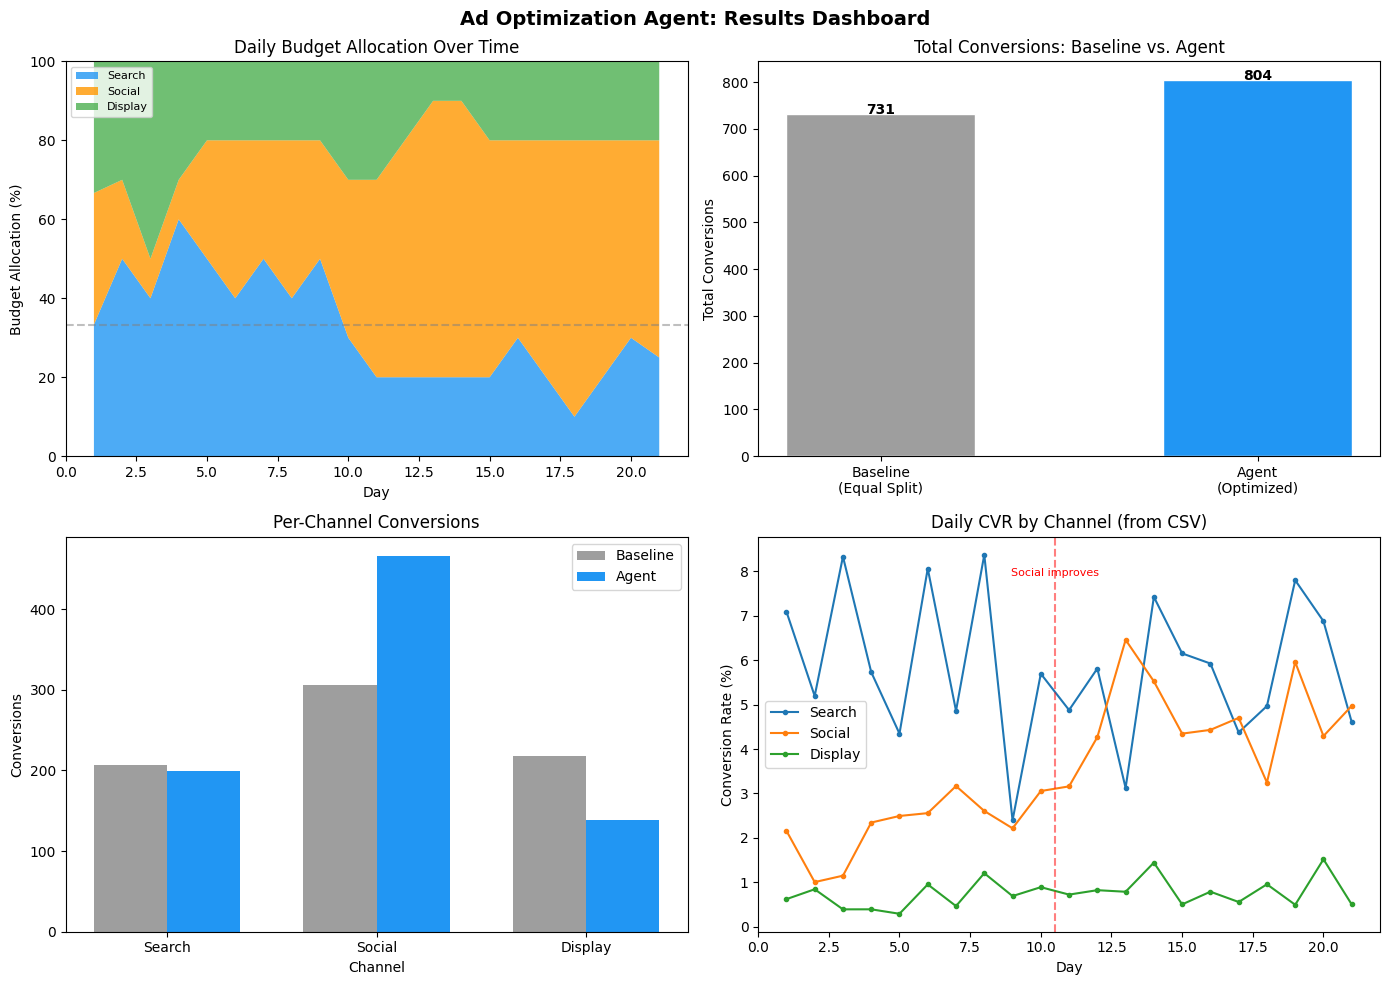


Chart saved as optimization_results.png


In [11]:
# ============================================================
# Visualization: Budget Allocation Over Time + Results Comparison
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Ad Optimization Agent: Results Dashboard", fontsize=14, fontweight="bold")

# ── Chart 1: Budget Allocation Over Time (Stacked Area) ──────
ax1 = axes[0][0]
days_range = list(range(1, NUM_DAYS + 1))

# Extract allocation percentages per channel per day
alloc_search = [tracker["allocation_history"][d-1]["Search"] for d in days_range]
alloc_social = [tracker["allocation_history"][d-1]["Social"] for d in days_range]
alloc_display = [tracker["allocation_history"][d-1]["Display"] for d in days_range]

ax1.stackplot(days_range, alloc_search, alloc_social, alloc_display,
              labels=["Search", "Social", "Display"],
              colors=["#2196F3", "#FF9800", "#4CAF50"], alpha=0.8)
ax1.set_xlabel("Day")
ax1.set_ylabel("Budget Allocation (%)")
ax1.set_title("Daily Budget Allocation Over Time")
ax1.legend(loc="upper left", fontsize=8)
ax1.set_ylim(0, 100)
ax1.axhline(y=33.33, color="gray", linestyle="--", alpha=0.5, label="Equal split")

# ── Chart 2: Conversions Comparison (Bar Chart) ──────────────
ax2 = axes[0][1]
categories = ["Baseline\n(Equal Split)", "Agent\n(Optimized)"]
conv_values = [baseline_total_conv, agent_total_conv]
colors = ["#9E9E9E", "#2196F3"]
bars = ax2.bar(categories, conv_values, color=colors, width=0.5, edgecolor="white")
ax2.set_ylabel("Total Conversions")
ax2.set_title("Total Conversions: Baseline vs. Agent")
for bar, val in zip(bars, conv_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}", ha="center", fontweight="bold")

# ── Chart 3: Per-Channel Conversions Comparison ──────────────
ax3 = axes[1][0]
x = np.arange(len(CHANNELS))
width = 0.35
b_conv_list = [channel_results[ch]["baseline_conv"] for ch in CHANNELS]
a_conv_list = [channel_results[ch]["agent_conv"] for ch in CHANNELS]

bars1 = ax3.bar(x - width/2, b_conv_list, width, label="Baseline", color="#9E9E9E")
bars2 = ax3.bar(x + width/2, a_conv_list, width, label="Agent", color="#2196F3")
ax3.set_xlabel("Channel")
ax3.set_ylabel("Conversions")
ax3.set_title("Per-Channel Conversions")
ax3.set_xticks(x)
ax3.set_xticklabels(CHANNELS)
ax3.legend()

# ── Chart 4: Daily Conversion Rate by Channel ────────────────
ax4 = axes[1][1]
for ch in CHANNELS:
    ch_data = df[df["channel"] == ch].copy()
    ch_data["cvr"] = ch_data["conversions"] / ch_data["clicks"].clip(lower=1) * 100
    days_list = list(range(1, len(ch_data) + 1))
    ax4.plot(days_list, ch_data["cvr"].values, marker="o", markersize=3, label=ch)
ax4.set_xlabel("Day")
ax4.set_ylabel("Conversion Rate (%)")
ax4.set_title("Daily CVR by Channel (from CSV)")
ax4.legend()
ax4.axvline(x=10.5, color="red", linestyle="--", alpha=0.5)
ax4.annotate("Social improves", xy=(10.5, ax4.get_ylim()[1]*0.9),
             fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("optimization_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nChart saved as optimization_results.png")

In [12]:
# ============================================================
# Full Decision Log
# ============================================================
# Every budget shift the agent made, with its reasoning.
# ============================================================

print("=" * 70)
print("COMPLETE AGENT DECISION LOG")
print("=" * 70)

for d in tracker["decisions"]:
    day = d["day"]
    prev = d["previous_allocation"]
    new = d["new_allocation"]
    reason = d["reasoning"]

    print(f"\n--- Day {day} ---")
    for ch in CHANNELS:
        diff = new[ch] - prev[ch]
        arrow = "+" if diff >= 0 else ""
        print(f"  {ch:<8s}: {prev[ch]:5.1f}% -> {new[ch]:5.1f}%  ({arrow}{diff:.1f}pp)")
    print(f"  Reasoning: {reason}")

print(f"\nTotal decisions logged: {len(tracker['decisions'])}")

COMPLETE AGENT DECISION LOG

--- Day 2 ---
  Search  :  33.3% ->  50.0%  (+16.7pp)
  Social  :  33.3% ->  20.0%  (-13.3pp)
  Display :  33.3% ->  30.0%  (-3.3pp)
  Reasoning: Search has the lowest CPA ($30.30) and the highest conversion rate (7.10%), making it the most efficient channel. Social has a higher CPA ($47.62) and lower conversion rate (2.16%), so I reduced its budget. Display has the highest CPA ($55.55) and lowest conversion rate (0.62%), so I also reduced its budget but kept it above 10% to maintain learning. This allocation maximizes budget efficiency while adhering to the 20 percentage point change limit.

--- Day 3 ---
  Search  :  50.0% ->  40.0%  (-10.0pp)
  Social  :  20.0% ->  10.0%  (-10.0pp)
  Display :  30.0% ->  50.0%  (+20.0pp)
  Reasoning: The Display channel has the lowest CPA ($25.64) and the highest number of conversions (13), making it the most efficient channel. The Search channel has a decent CPA ($41.67) and a good conversion rate (5.19%), so it will re